<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


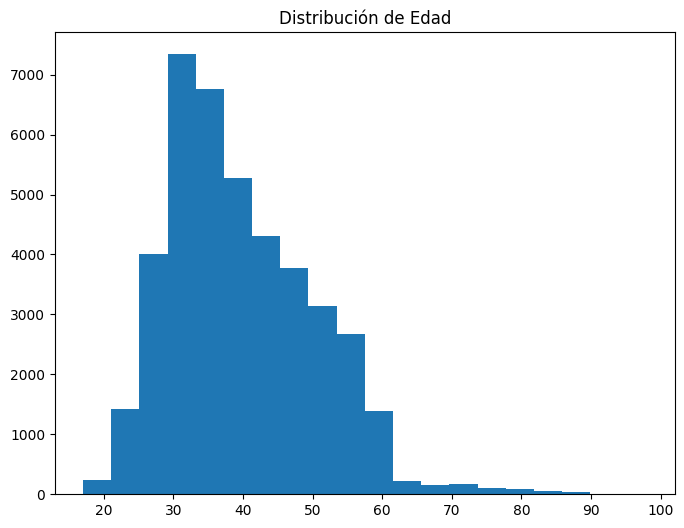

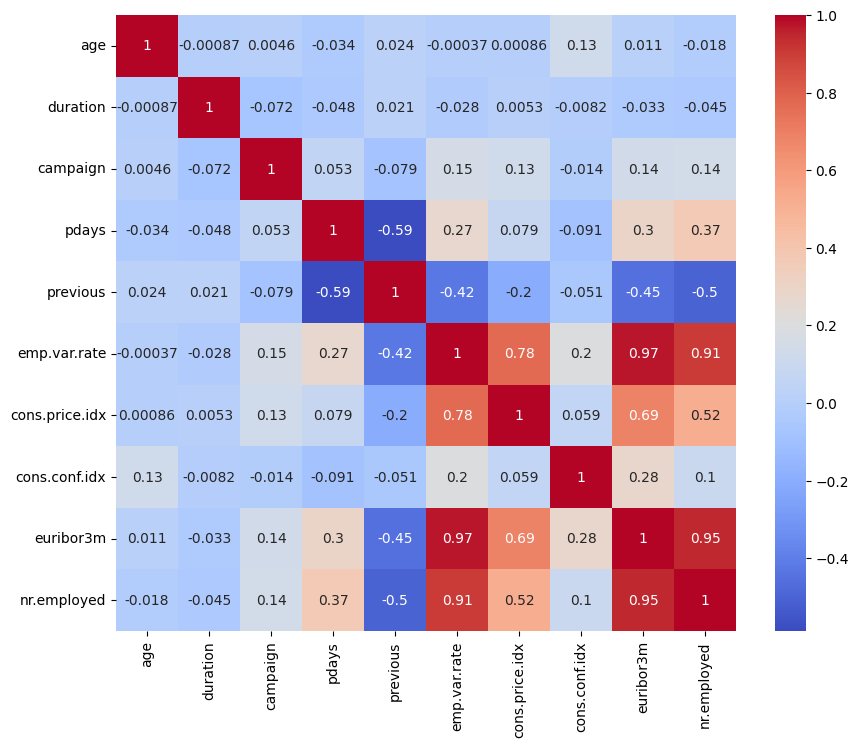

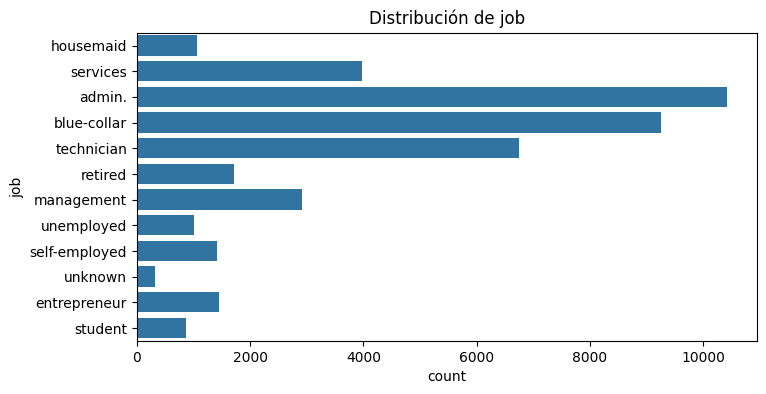

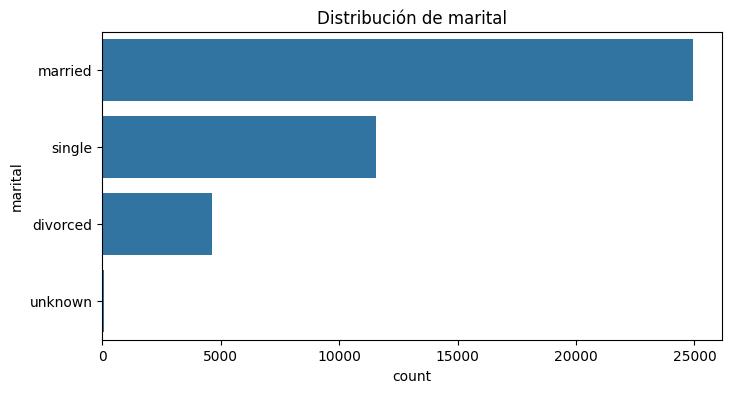

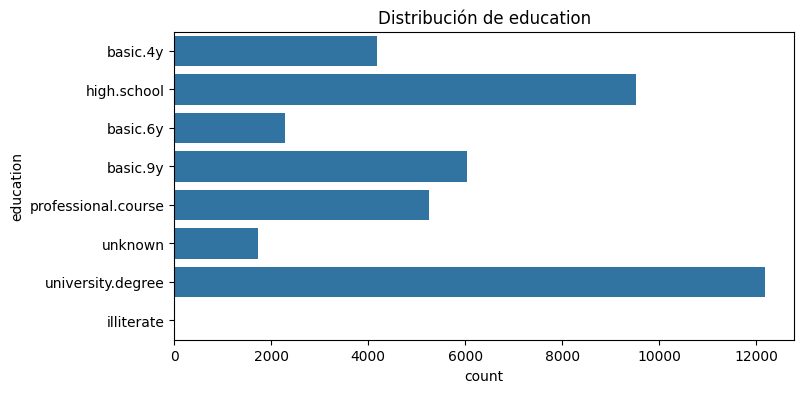

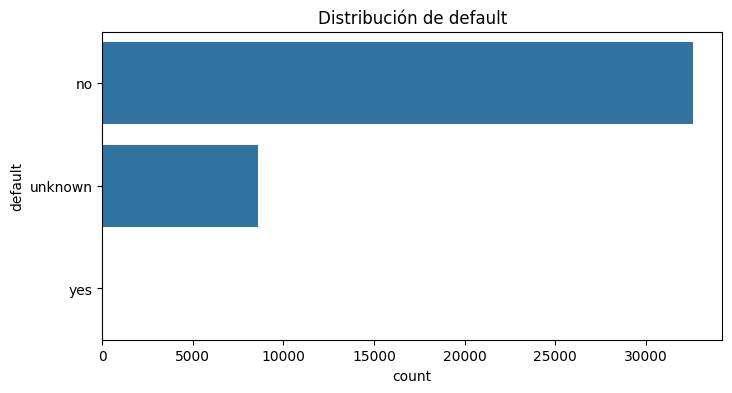

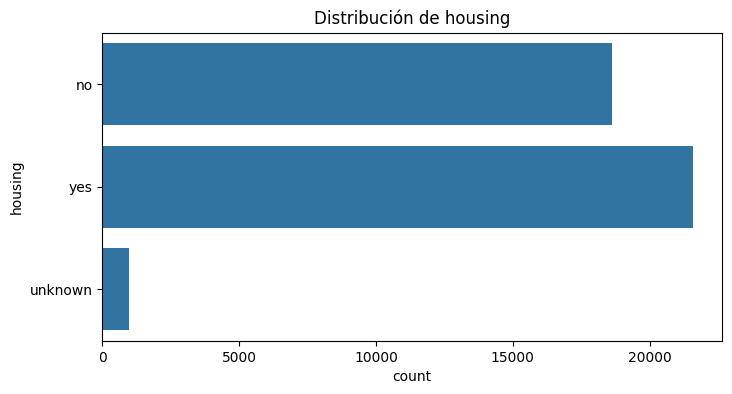

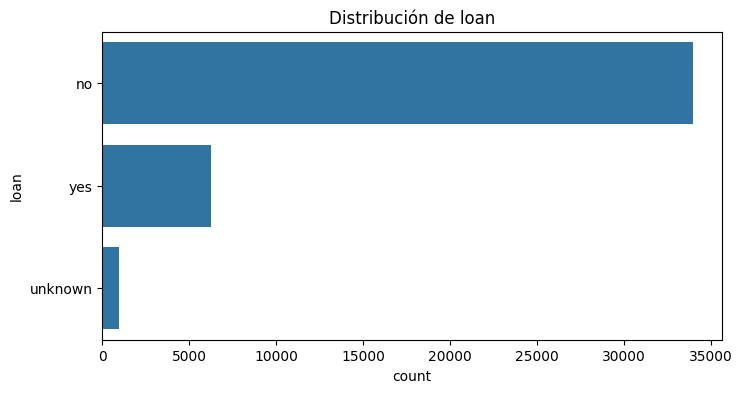

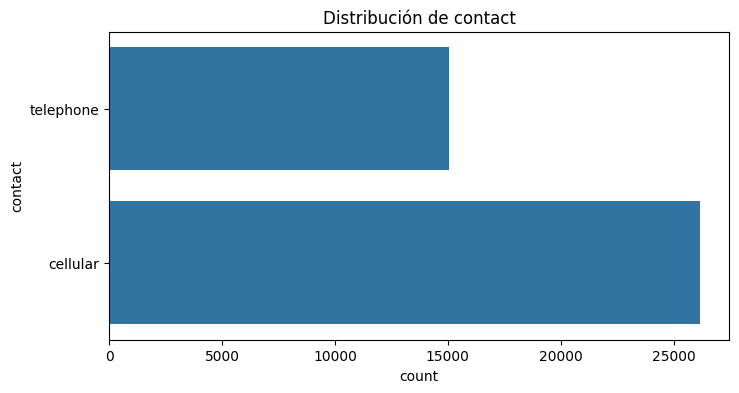

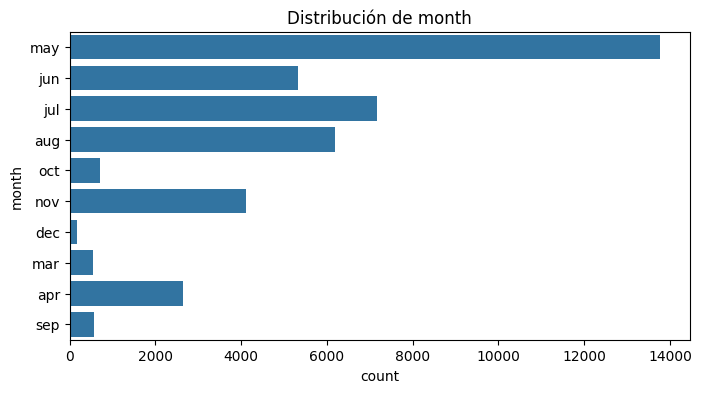

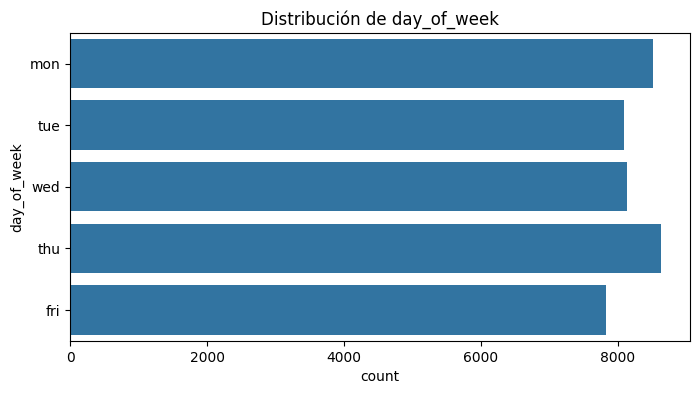

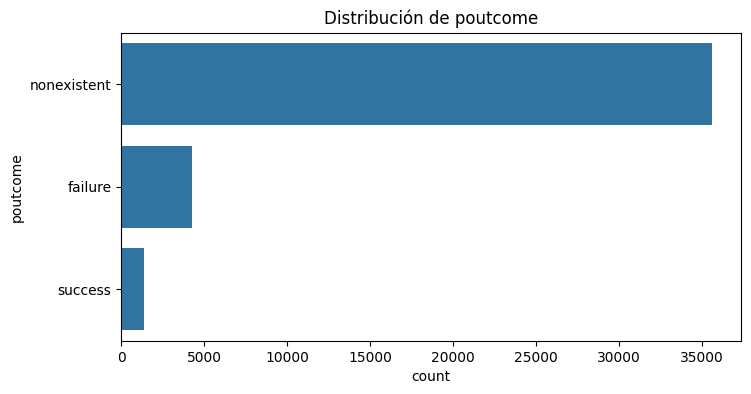

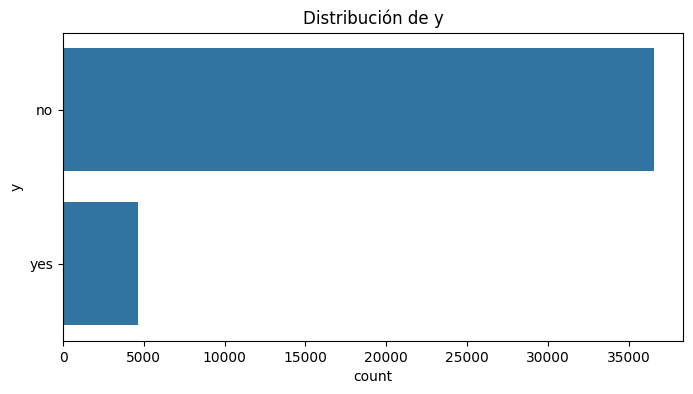

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Importar src
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from src.preprocessing import clean_and_save


# === 1. Cargar y limpiar dataset ===
df = clean_and_save(
    "../data/raw/bank-additional.csv",
    "../data/processed/bank_clean.csv"
)

# === 2. Info general ===
df.info()
display(df.describe(include='all').T)

# Crear carpeta de figuras
os.makedirs("../outputs/figures", exist_ok=True)

# === 3. Distribución de edad ===
plt.figure(figsize=(8,6))
plt.hist(df['age'], bins=20)
plt.title("Distribución de Edad")
plt.savefig("../outputs/figures/edad_histograma.png")
plt.show()

# === 4. Correlaciones de variables numéricas ===
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.savefig("../outputs/figures/correlation_matrix.png")
plt.show()

# === 5. Distribución de variables categóricas ===
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df)
    plt.title(f"Distribución de {col}")
    plt.savefig(f"../outputs/figures/{col}_countplot.png")
    plt.show()
